In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

credit_df = pd.read_csv("Credit_card.csv")
credit_df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2


In [42]:
gender_map = {'M':0, 'F':1}
credit_df['GENDER'] = credit_df['GENDER'].map(gender_map)

car_map = {'N':0, 'Y':1}
credit_df['Car_Owner'] = credit_df['Car_Owner'].map(car_map)

property_map = {'N':0, 'Y':1}
credit_df['Propert_Owner'] = credit_df['Propert_Owner'].map(property_map)

income_map = {'Commercial associate':0, 'Pensioner':1, 'State servant':2, 'Working':3}
credit_df['Type_Income'] = credit_df['Type_Income'].map(income_map)

education_map = {'Academic degree':0, 'Higher educaton':1, 'Incomplete higher':2, 
                 'Lower secondary':3, 'Secondary / secondary special':4}
credit_df['EDUCATION'] = credit_df['EDUCATION'].map(education_map)

married_map = {'Civil marriage':0, 'Married':1, 'Separated':2, 'Single / not married':3, 'Widow':4}
credit_df['Marital_status'] = credit_df['Marital_status'].map(married_map)

housing_map = {'Co-op apartment':0, 'House / apartment':1, 'Municipal apartment':2, 
               'Office apartment':3, 'Rented apartment':4, 'With parents':5}
credit_df['Housing_type'] = credit_df['Housing_type'].map(housing_map)

occupation_map = {'Accountants':0, 'Cleaning staff':1, 'Cooking staff':2, 
                  'Core staff':3, 'Drivers':4, 'HR staff':5, 'High skill tech staff':6, 
                  'IT staff':7, 'Laborers':8, 'Low-skill laborers':9, 'Managers':10, 
                  'Medicine staff':11, 'Private service staff':12, 'Realty agents':13,
                  'Sales staff':14, 'Secretaries':15, 'Security staff':16, 
                  'Waiters/barmen staff':17}
credit_df['Type_Occupation'] = credit_df['Type_Occupation'].map(occupation_map)

credit_df

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,0.0,1,1,0,180000.0,1,NaN,1,1,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,1.0,1,0,0,315000.0,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,1.0,1,0,0,315000.0,0,NaN,1,1,NaN,-586,1,1,1,0,NaN,2
3,5009749,1.0,1,0,0,NaN,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,1.0,1,0,0,315000.0,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,1.0,0,1,0,NaN,0,NaN,1,1,-11957.0,-2182,1,0,0,0,10.0,2
1544,5023655,1.0,0,0,0,225000.0,0,2.0,3,1,-10229.0,-1209,1,0,0,0,0.0,1
1545,5115992,0.0,1,1,2,180000.0,3,NaN,1,1,-13174.0,-2477,1,0,0,0,10.0,4
1546,5118219,0.0,1,0,0,270000.0,3,4.0,0,1,-15292.0,-645,1,1,1,0,4.0,2


In [43]:
credit_df.dropna()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
8,5010864,0.0,1,1,1,450000.0,0,4.0,1,1,-18173.0,-678,1,0,1,1,3.0,3
9,5010868,0.0,1,1,1,450000.0,1,4.0,1,1,-18173.0,-678,1,0,1,1,3.0,3
10,5010869,0.0,1,1,1,450000.0,0,4.0,3,1,-18173.0,-678,1,0,1,1,3.0,1
11,5018498,1.0,1,1,0,90000.0,3,4.0,1,1,-18950.0,-1002,1,1,1,0,2.0,2
13,5018503,1.0,1,1,0,90000.0,3,4.0,1,1,-18950.0,-1002,1,1,1,0,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1528,5033520,1.0,1,1,3,180000.0,3,4.0,1,2,-12559.0,-5862,1,0,1,0,11.0,5
1534,5096856,0.0,1,1,0,180000.0,0,4.0,1,1,-17975.0,-3476,1,0,0,0,4.0,2
1542,5118268,0.0,1,0,1,360000.0,2,4.0,1,1,-11294.0,-3536,1,0,1,0,4.0,3
1544,5023655,1.0,0,0,0,225000.0,0,2.0,3,1,-10229.0,-1209,1,0,0,0,0.0,1


In [44]:
credit_df.drop_duplicates()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,0.0,1,1,0,180000.0,1,NaN,1,1,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,1.0,1,0,0,315000.0,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,1.0,1,0,0,315000.0,0,NaN,1,1,NaN,-586,1,1,1,0,NaN,2
3,5009749,1.0,1,0,0,NaN,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,1.0,1,0,0,315000.0,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,1.0,0,1,0,NaN,0,NaN,1,1,-11957.0,-2182,1,0,0,0,10.0,2
1544,5023655,1.0,0,0,0,225000.0,0,2.0,3,1,-10229.0,-1209,1,0,0,0,0.0,1
1545,5115992,0.0,1,1,2,180000.0,3,NaN,1,1,-13174.0,-2477,1,0,0,0,10.0,4
1546,5118219,0.0,1,0,0,270000.0,3,4.0,0,1,-15292.0,-645,1,1,1,0,4.0,2


In [45]:
credit_df = credit_df[['Type_Income','Propert_Owner']]

X = np.array(credit_df['Type_Income']).reshape(-1,1)

y = np.array(credit_df['Propert_Owner']).reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [46]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [47]:
gender_list = credit_df['GENDER'].tolist()
gender_list = gender_list[0:50]
gender_list

KeyError: 'GENDER'

In [ ]:
filtered_list = list(filter(lambda num: int(num.replace(".0",""))>500,
                                    gender_list))

filtered_list

#i was attempting to get rid of the ".0" at the end of every entry in the gender column, but something went wrong here. 

AttributeError: 'float' object has no attribute 'replace'

The additional data cleaning that I did was dropping the null values and dropping the duplicates in the set. I then tried to get rid of the decimal points in the gender category since it is a binary category, but something went wrong. 

In [ ]:
credit_df['GENDER'].value_counts()

GENDER
1.0    973
0.0    568
Name: count, dtype: int64

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

I chose to oversample since there are only just over half the amount of males in the dataset as females. So, I want to duplicate some of the males to make the categories a bit more even. 

In [51]:
regression = LogisticRegression(random_state=42).fit(X_resampled, y_resampled)
y_pred = regression.predict(X_test)

y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [52]:
regression.score(X_test, y_test)

0.6516129032258065

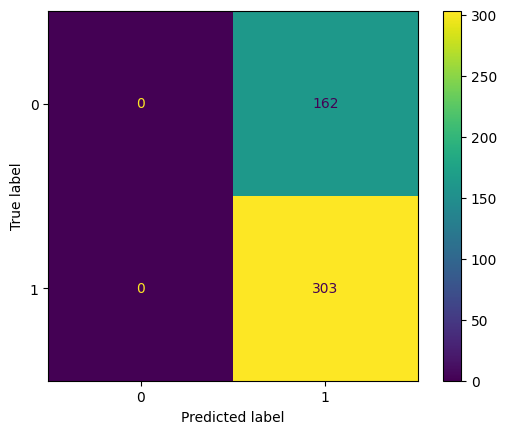

In [53]:
ConfusionMatrixDisplay.from_estimator(regression, X_test, y_test)

In [54]:
def precision_and_recall(calc_type:str, tp: int, tn: int,
                            fp:int, fn: int) -> float:
    if calc_type == "precision":
        value = tp/(tp + fp)
        return value
    
    elif calc_type == "recall":
        value = tp/(tp + fn)
        return value
    
    else: 
        error_msg = "ERROR"
        return error_msg

In [55]:
precision_and_recall("precision", 303, 0, 162, 0)

0.6516129032258065

I'm not seeing any difference between the original confusion matrix and the resampled confusion matrix. The precision is only 65 percent for both, which is a pretty badly performing model. It could definitely be improved. 

In [58]:
X = credit_df.drop('Propert_Owner', axis=1)
y = credit_df['Propert_Owner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 50)

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_resampled, y_resampled)
y_pred = knn.predict(X_test)
print(y_pred)
print(type(y_pred))

[0 1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0 1
 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 0
 0 1 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 0 1
 1 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 0 1 1 0 1 0 1 0 1 1 0
 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0
 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 1 1 1 0 0
 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 0 1
 1 0 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1
 1 0 1 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 1 1 1 1 0 1 0 1 1 0 0 1 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 1 1 1 0 1 1 1 0
 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 1 1 1 1 0 1 0 1 1 0 1 0 0 1 1 1 1 0 1 1
 0 0 1 0 0 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 0]
<class 'numpy.ndarray'>


c:\Users\kaste\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [59]:
print(knn.score(X_test, y_test))

0.4559139784946237


c:\Users\kaste\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


With the KNN model, there was an improvement of about one percent, which is pretty much nothing. It is still not a good model for this data, as the score is so far below one. This model could also use some serious improvement to make it more precise. 

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)
print(fpr, tpr)

[0.         0.50318471 1.        ] [0.         0.43506494 1.        ]


In [61]:
auc

0.4659401108445694

Text(0, 0.5, 'True Positive Rate')

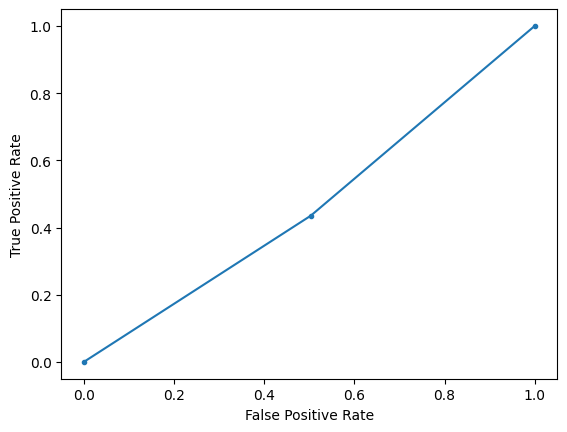

In [62]:
plt.plot(fpr, tpr, marker=".")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

In [68]:
from sklearn.svm import SVC

classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [69]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [70]:
accuracy_score = classifier.score(X_test, y_test)
print(accuracy_score)

0.6623655913978495


The SVM model did the best out of all four models, but not by a large margin. It is only about one percent better than the LogReg score, so there isn't much variation between the two. Overall, this is the best of these models to use on this dataset, however, it is not optimal, since the score is still so far from 1. 

Outlier detection involves finding the values in the dataset that are extremely far away from the rest of the data. This is important because those extreme values can throw the model predictions off severely. Since they don't fit into the general cluster of data, there is likely something weird going on with them and identitying and setting them aside is the best option in order to get a prediction with as little bias as possible. You can use a boxplot to visualize exactly where the outliers fall. Isolation forests and OneClassSVMs are also option to see the outliers in numeric form. 